In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
import pathlib
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [8]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS10_reward_cell_stability')
figdir.mkdir(exist_ok=True, parents=True)

In [4]:

rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])
        rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
        rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

        if sess.novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        pc_mask = sess.fam_place_cell_mask()+sess.nov_place_cell_mask()
        # print(pc_mask.shape)

        nov_mask= sess.trial_info['LR']==sess.novel_arm
        for day in range(6):

            day_mask = sess.trial_info['sess_num']==day

            tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_nov = np.nanargmax(tmat_nov, axis=0)
            rel_pos_nov = maxpos_nov-rz_nov[0]
            rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]-1))

            tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            # print(tmat_fam.shape)
            maxpos_fam = np.nanargmax(tmat_fam, axis=0)
            rel_pos_fam = maxpos_fam - rz_fam[0]
            rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]-1))

            r_cell_mask = (np.abs(rel_pos_fam-rel_pos_nov)<=2) * (maxpos_fam>10) * (maxpos_nov>10)
            
            
            
            rows.append({'cond': cond,
                        'mouse': mouse, 
                        'day': day,
                        'reward_cell_mask': r_cell_mask,
                        'reward_cell_pcnt': r_cell_mask.mean(),
                        })
                        
                   
df = pd.DataFrame(rows)



4467331.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467331.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467333.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
mCherry6
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry7
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry8
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
mCherry9
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
4467975.4
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
4467975.5
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
Cre7
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
Cre9
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


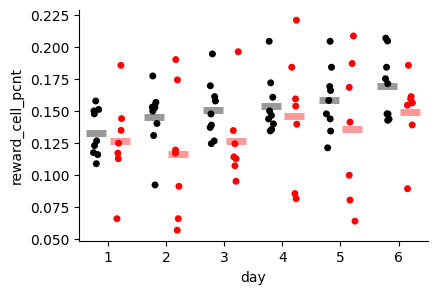

In [9]:
fig, ax = plt.subplots(figsize=[4.5,3])
sns.stripplot(data=df,
              hue = 'cond',
              hue_order = ['ctrl', 'ko'],
              palette=['black', 'red'],
              x='day',
              y='reward_cell_pcnt', 
              dodge=True, legend = False,
              )

sns.pointplot(data=df,
              x='day',
              y='reward_cell_pcnt',
              errorbar=None,
              hue='cond',
              dodge = .4,
              hue_order=('ctrl', 'ko'), 
              palette=['black', 'red'],
              ax=ax,
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
days = np.arange(6)
ax.set_xticks(days, labels=days+1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(figdir / "frac_rr_cells.pdf")

In [10]:
df.groupby('cond').reward_cell_pcnt.describe()

,count,mean,std,min,25%,50%,75%,max
cond,,,,,,,,
ctrl,54.0,0.152031,0.024686,0.092437,0.137716,0.148925,0.164876,0.206897
ko,42.0,0.133576,0.042631,0.057143,0.101840,0.134919,0.160845,0.220859


In [11]:
df['frac_logit'] = sp.special.logit(df['reward_cell_pcnt'])

aov = pg.mixed_anova(data=df, dv='frac_logit', within='day', between='cond', subject='mouse')
aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,0.874953,1,14,0.874953,2.790380,0.117028,0.166189,NaN
1,day,0.786487,5,70,0.157297,3.596591,0.005940,0.204391,0.526661
2,Interaction,0.159983,5,70,0.031997,0.731600,0.602155,0.049662,NaN


ValueError: x and y must have same first dimension, but have shapes (6,) and (5,)

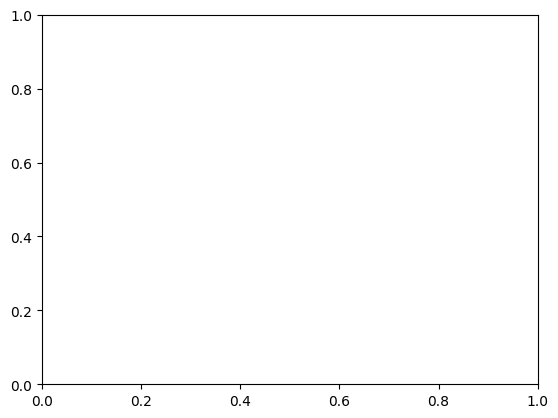

In [3]:
# exclude cells that are a reward cell on any day 
fig, ax = plt.subplots()
days = np.arange(6)
for color, mice in zip(('black', 'red'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        rcell_masks = np.vstack(df.loc[df['mouse']==mouse, 'reward_cell_mask'].values)
        ax.plot(days, rcell_masks.mean(axis=-1), color=color, alpha=.4)

ax.set_xticks(days, labels=days+1)
ax.set_xlabel('Days')
ax.set_ylabel('Pcnt RR cells')

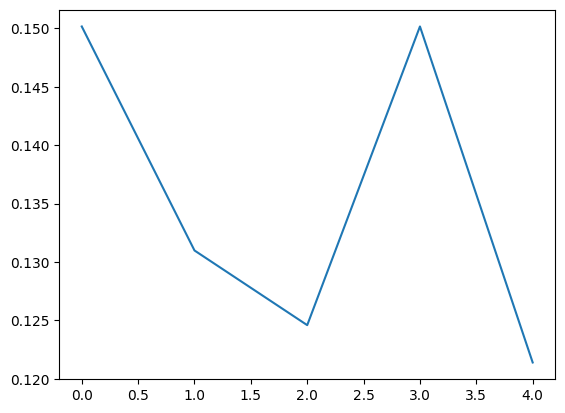

In [29]:
fig,ax = plt.subplots()
ax.plot(rcell_masks.mean(axis=1))

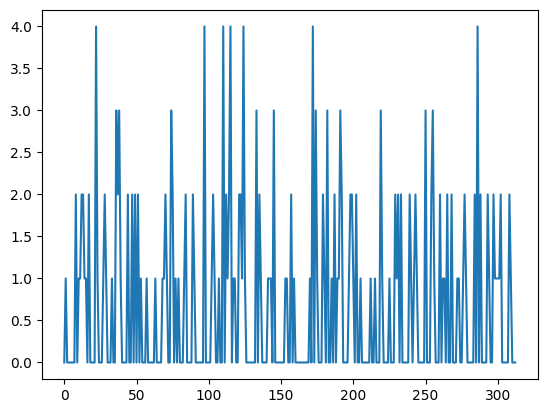

In [26]:
fig, ax = plt.subplots()
ax.plot(rcell_masks.sum(axis=0))

In [28]:
(rcell_masks.sum(axis=0)>1).mean()

np.float64(0.19488817891373802)